In [7]:
import pandas as pd
import numpy as np
from autogluon.tabular import TabularDataset, TabularPredictor
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
rpi4a = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/offscreen/rpi-4a_chrome_offscreen.csv")
rpi8a = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/offscreen/rpi-8a_chrome_offscreen.csv")
rpi8b = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/offscreen/rpi-8b_chrome_offscreen.csv")
rpi8c = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/offscreen/rpi-8c_chrome_offscreen.csv")
rpi8d = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/offscreen/rpi-8d_chrome_offscreen.csv")

C:\Users\zac\AppData\Local\Temp\ipykernel_6708\152768638.py:4: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  rpi8c = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/offscreen/rpi-8c_chrome_offscreen.csv")


In [9]:
df = pd.concat([rpi4a[:1000], rpi8a[:1000], rpi8b[:1000], rpi8c[:1000], rpi8d[:1000]])
df = df.sample(frac=1, random_state=29).reset_index(drop=True)
np.random.seed(29)

In [10]:
df.head()

,label,Feature 0,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6,Feature 7,Feature 8,...,Feature 1014,Feature 1015,Feature 1016,Feature 1017,Feature 1018,Feature 1019,Feature 1020,Feature 1021,Feature 1022,Feature 1023
0,rpi_8b,8.3,18.6,17.2,19.0,39.5,20.4,16.3,15.9,15.9,...,16.8,16.7,16.8,16.8,16.8,16.8,16.9,16.7,16.5,NaN
1,rpi_8b,7.4,18.3,18.0,18.0,35.6,19.4,17.8,16.3,16.3,...,15.7,15.6,15.6,15.6,15.6,15.7,15.6,15.7,15.7,NaN
2,rpi-8a,5.5,16.7,15.7,17.2,27.5,15.7,15.6,15.5,15.6,...,16.2,16.1,16.3,16.2,16.2,16.3,16.6,16.3,16.4,16.5
3,rpi-4a,5.4,17.3,16.5,16.0,16.5,28.4,15.6,15.7,16.1,...,16.1,16.2,16.3,16.0,15.8,15.9,16.1,16.2,16.2,16.2
4,rpi_8b,9.5,17.9,17.7,19.0,44.8,16.4,15.8,16.1,15.6,...,16.9,16.8,16.7,16.9,16.7,16.5,16.7,16.6,16.6,NaN


In [11]:
len(df)

5000

: 

In [ ]:
import os
os.environ['OPENBLAS_NUM_THREADS'] = '20'
stats_df = pd.DataFrame(columns=['data_amount', 'precision', 'recall', 'f1'])
best_model = {}
best_features = {}

for i in range(1000, 5000, 1000):
    train_data = df.head(i)
    test_data = df.tail(1000)

    predictor = TabularPredictor(label='label').fit(train_data, num_gpus=1, presets='medium_quality')
    y_pred = predictor.predict(test_data)
    y_pred_proba = predictor.predict_proba(test_data)
    results = predictor.evaluate(test_data, detailed_report=True)['classification_report']['weighted avg']

    new_row = {'data_amount': i, 'precision': results['precision'], 'recall':results['recall'], 'f1':results['f1-score']}
    stats_df.loc[len(stats_df)] = new_row

    model_leaderboard = predictor.leaderboard(test_data)
    # Which models came in the top three on the leaderboard most often?
    if model_leaderboard.loc[0]['model'] not in best_model:
        best_model[model_leaderboard.loc[0]['model']] = 1
    else:
        best_model[model_leaderboard.loc[0]['model']] += 1

    if model_leaderboard.loc[1]['model'] not in best_model:
        best_model[model_leaderboard.loc[1]['model']] = 1
    else:
        best_model[model_leaderboard.loc[1]['model']] += 1

    if model_leaderboard.loc[2]['model'] not in best_model:
        best_model[model_leaderboard.loc[2]['model']] = 1
    else:
        best_model[model_leaderboard.loc[2]['model']] += 1


    feature_importance = predictor.feature_importance(test_data)
    # Which features has the highest importance most often?
    if feature_importance.index[0] not in best_features:
        best_features[feature_importance.index[0]] = 1
    else:
        best_features[feature_importance.index[0]] += 1

    if feature_importance.index[1] not in best_features:
        best_features[feature_importance.index[1]] = 1
    else:
        best_features[feature_importance.index[1]] += 1

    if feature_importance.index[2] not in best_features:
        best_features[feature_importance.index[2]] = 1
    else:
        best_features[feature_importance.index[2]] += 1

No path specified. Models will be saved in: "AutogluonModels\ag-20250203_043515"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.2
Python Version:     3.11.11
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26100
CPU Count:          32
Memory Avail:       55.74 GB / 63.72 GB (87.5%)
Disk Space Avail:   1279.99 GB / 1906.98 GB (67.1%)
Presets specified: ['medium_quality']
Beginning AutoGluon training ...
AutoGluon will save models to "c:\Users\zac\Documents\github\IoT-GPU-ID\Experiment 1 - DrawnApart\AutogluonModels\ag-20250203_043515"
Train Data Rows:    1000
Train Data Columns: 1024
Label Column:       label
AutoGluon infers your prediction problem is: 'multiclass' (because dtype of label-column == object).
	5 unique label values:  ['rpi_8b', 'rpi-8a', 'rpi-4a', 'rpi-8d', 'rpi_8c']
	If 'multiclass' is not the correct problem_type, please manually specify the problem_type parameter during Predictor

In [7]:
stats_df

,data_amount,precision,recall,f1
0,1000,0.790466,0.782,0.783623
1,2000,0.821322,0.818,0.817346
2,3000,0.835239,0.832,0.832263
3,4000,0.854682,0.852,0.852105


<Axes: xlabel='data_amount', ylabel='value'>

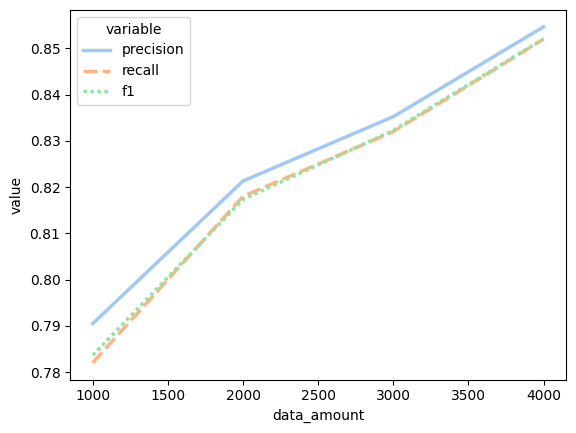

In [8]:
sns.lineplot(data=pd.melt(stats_df, ['data_amount']), x='data_amount', y='value', style="variable", hue='variable', palette="pastel", linewidth=2.5)

In [9]:
best_model

{'LightGBMXT': 3, 'WeightedEnsemble_L2': 4, 'LightGBM': 4, 'XGBoost': 1}

([<matplotlib.patches.Wedge at 0x7fa8c2b32650>,
 [Text(0.7778174593052024, 0.7778174593052023, 'LightGBMXT'),
  Text(-0.9526279613277876, 0.5499999702695114, 'WeightedEnsemble_L2'),
  Text(1.0298943251329445e-07, -1.0999999999999954, 'LightGBM'),
  Text(1.0625184466801036, -0.2847008086825535, 'XGBoost')],
 [Text(0.4242640687119285, 0.42426406871192845, '25%'),
  Text(-0.5196152516333387, 0.29999998378336984, '33%'),
  Text(5.61760540981606e-08, -0.5999999999999974, '33%'),
  Text(0.5795555163709656, -0.1552913501904837, '8%')])

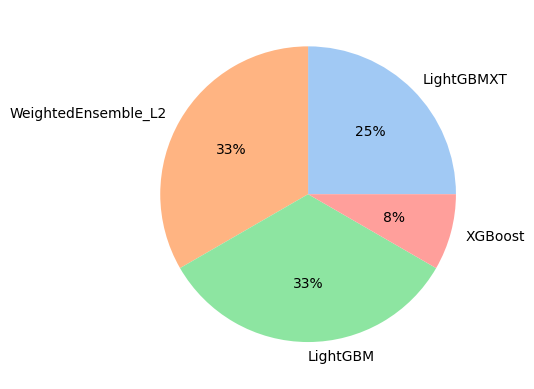

In [10]:
colors = sns.color_palette('pastel')[0:20]
plt.pie(list(best_model.values()), labels=list(best_model), colors = colors, autopct='%.0f%%')

In [11]:
best_features

{'Feature 1023': 4, 'Feature 18': 4, 'Feature 19': 2, 'Feature 86': 2}

([<matplotlib.patches.Wedge at 0x7faa0008b650>,
 [Text(0.5499999702695115, 0.9526279613277875, 'Feature 1023'),
  Text(-1.0999999999999954, -1.0298943258065002e-07, 'Feature 18'),
  Text(1.5448414935947287e-07, -1.0999999999999892, 'Feature 19'),
  Text(0.9526280385698485, -0.5499998364823061, 'Feature 86')],
 [Text(0.2999999837833699, 0.5196152516333385, '33%'),
  Text(-0.5999999999999974, -5.6176054134900006e-08, '33%'),
  Text(8.426408146880338e-08, -0.5999999999999941, '17%'),
  Text(0.5196152937653719, -0.29999991080853056, '17%')])

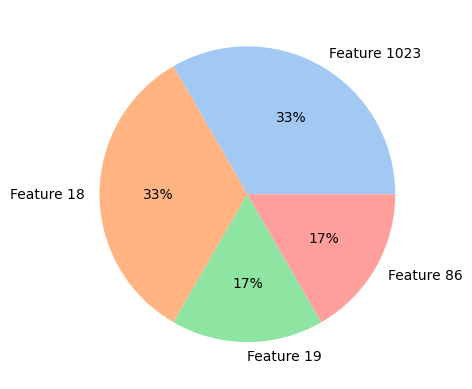

In [12]:
plt.pie(list(best_features.values()), labels=list(best_features), colors = colors, autopct='%.0f%%')

In [13]:
feature_importance

,importance,stddev,p_value,n,p99_high,p99_low
Feature 1023,0.4220,0.011662,6.991449e-08,5,0.446012,0.397988
Feature 18,0.0290,0.006633,3.067542e-04,5,0.042658,0.015342
Feature 19,0.0220,0.003937,1.179868e-04,5,0.030106,0.013894
Feature 86,0.0200,0.005916,8.206447e-04,5,0.032181,0.007819
Feature 5,0.0142,0.004970,1.540356e-03,5,0.024433,0.003967
...,...,...,...,...,...,...
Feature 726,-0.0018,0.000837,9.957095e-01,5,-0.000077,-0.003523
Feature 333,-0.0018,0.001304,9.816590e-01,5,0.000885,-0.004485
Feature 33,-0.0020,0.001225,9.891285e-01,5,0.000522,-0.004522
Feature 422,-0.0020,0.000707,9.984009e-01,5,-0.000544,-0.003456
